In [7]:
import pandas as pd

full_dataset = pd.read_csv("features.csv")

print(full_dataset.head())

train_dataset = full_dataset.sample(frac=0.8, random_state=42)
test_dataset = full_dataset.drop(train_dataset.index)

   packet_size       ttl  protocol  src_port  dst_port  flags  tcp_window  \
0     0.044118  0.196850  0.352941  0.007263  0.799482   0.96    0.001175   
1     0.003443  0.196850  0.352941  0.007263  0.799482   1.00    0.001175   
2     0.001722  0.251969  0.352941  0.799482  0.007263   0.64    0.001236   
3     0.003443  0.251969  0.352941  0.799482  0.007263   0.96    0.001236   
4     0.001722  0.251969  0.352941  0.799482  0.007263   0.68    0.001236   

   payload_size  
0      0.042457  
1      0.001724  
2      0.000000  
3      0.001724  
4      0.000000  


In [8]:
# Write a autoencoder net with binary intermediate layers

import torch
import torch.nn as nn


class BinarizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        out = torch.sign(x)
        out[out == 0] = 1
        return out

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        mask = (x.abs() <= 1).float()
        return grad_output * mask


def binarize(x):
    return BinarizeSTE.apply(x)


class BinaryHiddenLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x):
        return binarize(self.linear(x))


class BinaryAutoencoder(nn.Module):
    def __init__(self, input_size=8, hidden_size=48, latent_size=8):
        super().__init__()

        self.encoder = nn.Sequential(
            BinaryHiddenLayer(input_size, hidden_size),
            BinaryHiddenLayer(hidden_size, hidden_size),
            BinaryHiddenLayer(hidden_size, hidden_size),
            BinaryHiddenLayer(hidden_size, latent_size),
        )

        self.decoder = nn.Sequential(
            BinaryHiddenLayer(latent_size, hidden_size),
            BinaryHiddenLayer(hidden_size, hidden_size),
            BinaryHiddenLayer(hidden_size, hidden_size),
            nn.Linear(hidden_size, input_size),
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction, latent


In [12]:
import numpy as np
import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x = torch.tensor(train_dataset.to_numpy(dtype=np.float32)).to(device)
def train_test_model(data, size):
    model = BinaryAutoencoder(input_size=data.shape[1], hidden_size=size*4, latent_size=size).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epochs = 40000
    pbar = tqdm.tqdm(range(epochs))
    losses = []
    for epoch in pbar:
        optimizer.zero_grad()
        reconstruction, latent = model(x)
        loss = torch.nn.functional.mse_loss(reconstruction, x)
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=loss.item())
        losses.append(loss.item())
    return sum(losses)/len(losses)

measured_losses = []

for i in range(1, 17):
    print(f"Training model with latent size {i} and hidden size {i*4}")
    loss = train_test_model(x, i)
    measured_losses.append(loss)
    print(f"Final loss for latent size {i} and hidden size {i*4}: {loss}")


Using device: cuda
Training model with latent size 1 and hidden size 4


100%|██████████| 40000/40000 [07:07<00:00, 93.62it/s, loss=0.0581]


Final loss for latent size 1 and hidden size 4: 0.057636772484891116
Training model with latent size 2 and hidden size 8


100%|██████████| 40000/40000 [05:34<00:00, 119.42it/s, loss=0.031] 


Final loss for latent size 2 and hidden size 8: 0.04202614626297727
Training model with latent size 3 and hidden size 12


...

Final loss for latent size 14 and hidden size 56: 0.002769650999266014
Training model with latent size 15 and hidden size 60


100%|██████████| 40000/40000 [06:39<00:00, 100.07it/s, loss=0.00152] 


Final loss for latent size 15 and hidden size 60: 0.002580962082791666
Training model with latent size 16 and hidden size 64


100%|██████████| 40000/40000 [06:44<00:00, 98.95it/s, loss=0.00123]  

Final loss for latent size 16 and hidden size 64: 0.002259166241873754


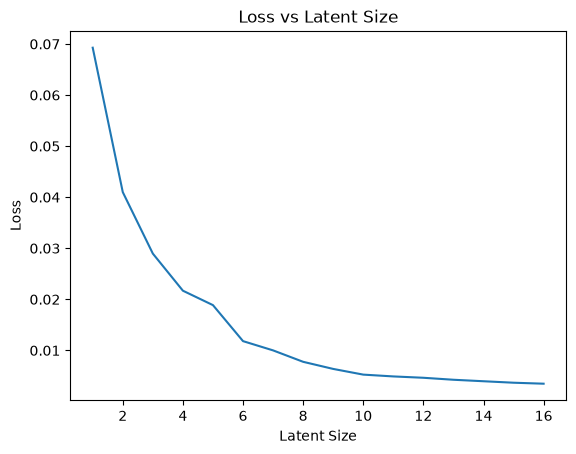

In [11]:
from matplotlib import pyplot as plt

plt.plot(range(1, 17), measured_losses)
plt.xlabel("Latent Size")
plt.ylabel("Loss")
plt.title("Loss vs Latent Size")
plt.show()